In [8]:
import pandas as pd 
import numpy as np

In [7]:
!pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.7 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.7 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.7 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.7 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.7 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.7 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.7 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.7 MB 1.0 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.7 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/9.7 MB 1.1 MB/s eta 0:00:07
   ----------- ------------

In [9]:
df=pd.read_csv('../data/healthcare-wearable-vital-streams.csv')
df.head()

,stream_id,device_id,user_id,timestamp,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius,activity_type,anomaly_flag,sensor_status,device_firmware_version,location_latitude,location_longitude
0,stream001,deviceA,userX,2024-04-01T08:00:00Z,62.5,116.0,74.0,15.0,98.2,35.1,resting,False,normal,2.3.5,40.7128,-74.0060
1,stream002,deviceB,userY,2024-04-01T08:02:00Z,77.2,128.0,82.0,17.0,97.5,35.8,walking,False,normal,3.1.2,41.8781,-87.6298
2,stream003,deviceC,userZ,2024-04-01T08:04:00Z,158.3,182.0,104.0,39.0,89.9,38.4,running,True,battery_low,1.4.0,34.0522,-118.2437
3,stream004,deviceD,userW,2024-04-01T08:06:00Z,51.7,105.0,66.0,12.0,99.1,34.2,sleeping,False,normal,2.0.1,48.8566,2.3522
4,stream005,deviceE,userV,2024-04-01T08:08:00Z,96.4,133.0,90.0,23.0,96.7,36.9,cycling,False,normal,4.2.3,52.5200,13.4050


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stream_id                 200 non-null    str    
 1   device_id                 200 non-null    str    
 2   user_id                   200 non-null    str    
 3   timestamp                 200 non-null    str    
 4   heart_rate_bpm            189 non-null    float64
 5   blood_pressure_systolic   199 non-null    float64
 6   blood_pressure_diastolic  199 non-null    float64
 7   respiratory_rate          198 non-null    float64
 8   blood_oxygen_saturation   200 non-null    float64
 9   skin_temperature_celsius  198 non-null    float64
 10  activity_type             200 non-null    str    
 11  anomaly_flag              200 non-null    bool   
 12  sensor_status             200 non-null    str    
 13  device_firmware_version   200 non-null    str    
 14  location_latitude    

In [13]:
df.describe()

,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius,location_latitude,location_longitude
count,189.000000,199.000000,199.000000,198.000000,200.000000,198.000000,200.000000,200.000000
mean,100.591005,140.723618,90.010050,23.838384,91.672000,36.446970,29.419465,26.186387
std,47.314062,39.022772,23.827662,14.074282,10.284922,4.241213,36.414784,84.180641
min,25.000000,52.000000,31.000000,5.000000,50.000000,20.000000,-90.000000,-180.000000
25%,62.900000,118.000000,76.000000,14.000000,90.325000,34.800000,25.204800,-3.703800
50%,76.400000,132.000000,85.000000,18.000000,96.100000,36.100000,38.861500,18.068600
75%,136.900000,154.000000,101.000000,29.750000,98.025000,38.200000,51.165700,103.819800
max,203.100000,250.000000,150.000000,60.000000,99.800000,45.000000,90.000000,180.000000


In [16]:
df.isnull().sum()

stream_id                   0
device_id                   0
user_id                     0
timestamp                   0
heart_rate_bpm              0
blood_pressure_systolic     1
blood_pressure_diastolic    0
respiratory_rate            1
blood_oxygen_saturation     0
skin_temperature_celsius    0
activity_type               0
anomaly_flag                0
sensor_status               0
device_firmware_version     0
location_latitude           0
location_longitude          0
dtype: int64

In [15]:
q1 = df["heart_rate_bpm"].quantile(0.25)
q3 = df["heart_rate_bpm"].quantile(0.75)
iqr = q3 - q1

df = df[
    (df["heart_rate_bpm"] >= q1 - 1.5*iqr) &
    (df["heart_rate_bpm"] <= q3 + 1.5*iqr)
]

In [17]:
df = df.dropna(subset=["blood_pressure_systolic", "respiratory_rate"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 187 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stream_id                 187 non-null    str    
 1   device_id                 187 non-null    str    
 2   user_id                   187 non-null    str    
 3   timestamp                 187 non-null    str    
 4   heart_rate_bpm            187 non-null    float64
 5   blood_pressure_systolic   187 non-null    float64
 6   blood_pressure_diastolic  187 non-null    float64
 7   respiratory_rate          187 non-null    float64
 8   blood_oxygen_saturation   187 non-null    float64
 9   skin_temperature_celsius  187 non-null    float64
 10  activity_type             187 non-null    str    
 11  anomaly_flag              187 non-null    bool   
 12  sensor_status             187 non-null    str    
 13  device_firmware_version   187 non-null    str    
 14  location_latitude         

In [23]:
df.describe()

,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius,location_latitude,location_longitude
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,90.252288,129.320261,83.071895,18.699346,96.224837,35.964706,35.350931,24.227799
std,35.598889,19.377705,12.008826,7.336898,3.181180,1.674518,22.902262,75.795888
min,40.100000,91.000000,58.000000,8.000000,82.000000,32.700000,-37.813600,-123.120700
25%,62.500000,118.000000,76.000000,14.000000,94.900000,34.800000,31.230400,-3.188300
50%,72.800000,127.000000,81.000000,17.000000,97.300000,35.700000,40.416800,18.064900
75%,126.000000,141.000000,91.000000,22.000000,98.300000,36.800000,50.110900,80.270700
max,170.000000,189.000000,120.000000,39.000000,99.800000,41.100000,64.963100,151.209300


In [20]:
df = df[(df["heart_rate_bpm"] > 40) & (df["heart_rate_bpm"] < 180)]

In [22]:
df = df[df["respiratory_rate"] < 40]
df = df[df["blood_oxygen_saturation"] > 80]
df = df[df["skin_temperature_celsius"] < 42]

array([[<Axes: title={'center': 'heart_rate_bpm'}>,
        <Axes: title={'center': 'blood_pressure_systolic'}>,
        <Axes: title={'center': 'blood_pressure_diastolic'}>],
       [<Axes: title={'center': 'respiratory_rate'}>,
        <Axes: title={'center': 'blood_oxygen_saturation'}>,
        <Axes: title={'center': 'skin_temperature_celsius'}>],
       [<Axes: title={'center': 'location_latitude'}>,
        <Axes: title={'center': 'location_longitude'}>, <Axes: >]],
      dtype=object)

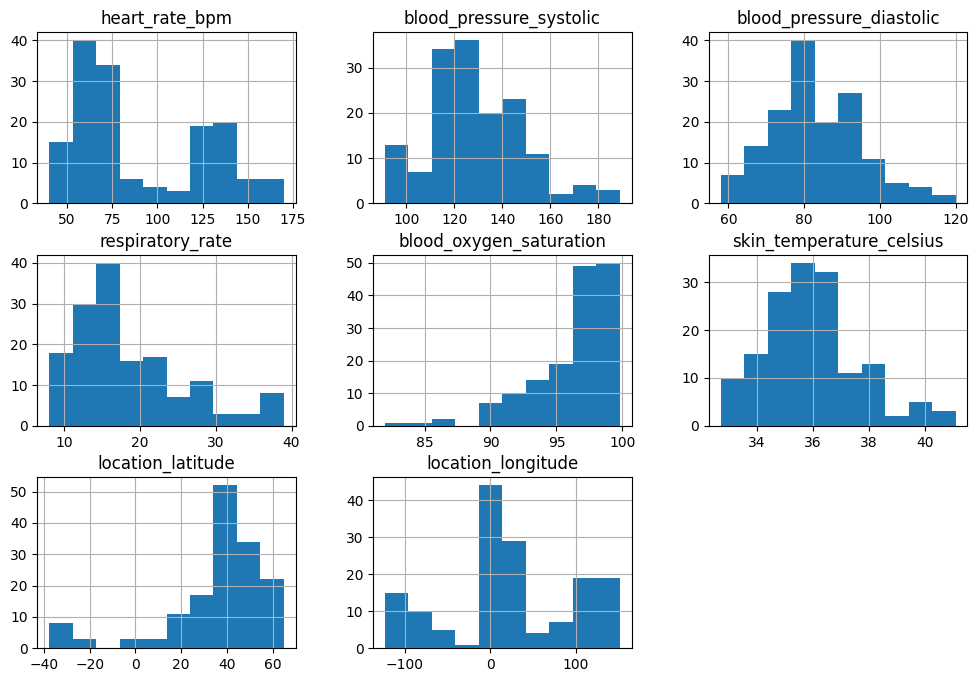

In [27]:
df.hist(figsize=(12,8))

In [25]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 4.4 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 5.2 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 5.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 6.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 7.4 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.3 MB 7.2 MB/s eta 0:00:01
   ------------------------------- --------

In [26]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [31]:
from sklearn.preprocessing import StandardScaler

features = [
    "heart_rate_bpm",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "respiratory_rate",
    "blood_oxygen_saturation",
    "skin_temperature_celsius"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
pd.DataFrame(X_scaled, columns=features).describe()

,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius
count,1.530000e+02,1.530000e+02,1.530000e+02,1.530000e+02,1.530000e+02,1.530000e+02
mean,3.308900e-16,-1.153761e-16,3.047671e-16,-1.422246e-16,-4.237714e-15,2.210287e-15
std,1.003284e+00,1.003284e+00,1.003284e+00,1.003284e+00,1.003284e+00,1.003284e+00
min,-1.413443e+00,-1.984038e+00,-2.094646e+00,-1.463082e+00,-4.486245e+00,-1.956042e+00
25%,-7.821432e-01,-5.861085e-01,-5.908255e-01,-6.426121e-01,-4.178285e-01,-6.978313e-01
50%,-4.918581e-01,-1.201319e-01,-1.730977e-01,-2.323771e-01,3.390862e-01,-1.585980e-01
75%,1.007478e+00,6.047205e-01,6.623579e-01,4.513479e-01,6.544674e-01,5.004649e-01
max,2.247531e+00,3.089929e+00,3.085179e+00,2.776013e+00,1.127539e+00,3.076802e+00


In [32]:
df.head()

,stream_id,device_id,user_id,timestamp,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius,activity_type,anomaly_flag,sensor_status,device_firmware_version,location_latitude,location_longitude
0,stream001,deviceA,userX,2024-04-01T08:00:00Z,62.5,116.0,74.0,15.0,98.2,35.1,resting,False,normal,2.3.5,40.7128,-74.0060
1,stream002,deviceB,userY,2024-04-01T08:02:00Z,77.2,128.0,82.0,17.0,97.5,35.8,walking,False,normal,3.1.2,41.8781,-87.6298
2,stream003,deviceC,userZ,2024-04-01T08:04:00Z,158.3,182.0,104.0,39.0,89.9,38.4,running,True,battery_low,1.4.0,34.0522,-118.2437
3,stream004,deviceD,userW,2024-04-01T08:06:00Z,51.7,105.0,66.0,12.0,99.1,34.2,sleeping,False,normal,2.0.1,48.8566,2.3522
4,stream005,deviceE,userV,2024-04-01T08:08:00Z,96.4,133.0,90.0,23.0,96.7,36.9,cycling,False,normal,4.2.3,52.5200,13.4050


In [30]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 1.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.0 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.0 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 1.9 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.0 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.0 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.0 MB 2.2 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 2.3 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 2.5 MB/s eta 0:00:02
   ------------------------------ --------- 6.

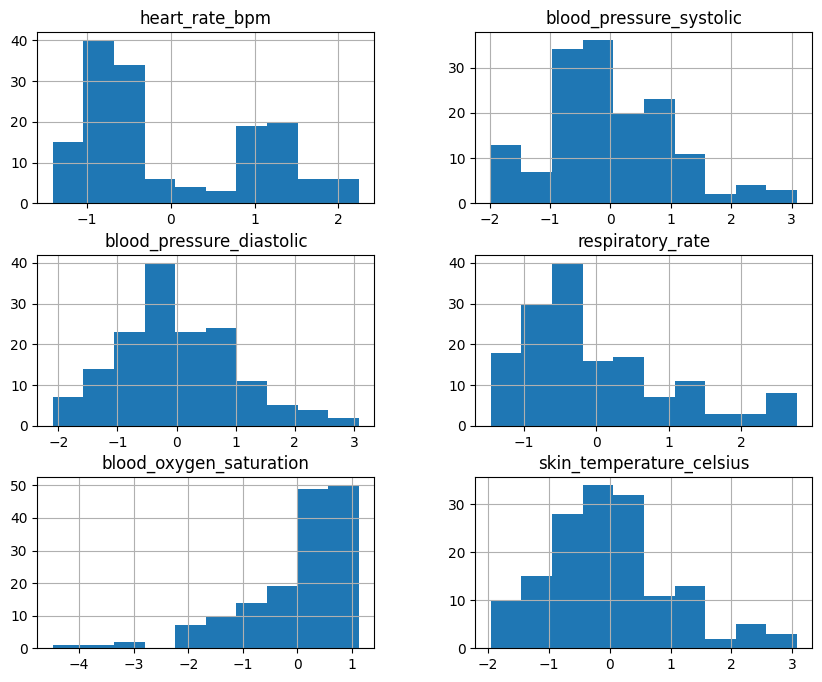

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.hist(figsize=(10,8))
plt.show()

In [35]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [36]:
df["anomaly_score"] = model.decision_function(X_scaled)
df["anomaly_label"] = model.predict(X_scaled)

In [37]:
df['anomaly_label'].value_counts()

anomaly_label
 1    137
-1     16
Name: count, dtype: int64

In [38]:
df[df["anomaly_label"] == -1][features]

,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius
2,158.3,182.0,104.0,39.0,89.9,38.4
5,133.7,162.0,108.0,29.0,92.6,37.7
9,42.5,99.0,60.0,10.0,98.6,33.5
13,48.3,96.0,58.0,9.0,99.3,33.3
23,40.1,95.0,59.0,8.0,99.8,33.1
34,144.2,177.0,120.0,37.0,84.3,40.2
46,142.3,168.0,115.0,38.0,85.9,39.6
53,160.4,189.0,112.0,38.0,93.2,41.1
62,135.5,153.0,101.0,36.0,92.3,39.8
87,159.6,176.0,109.0,39.0,91.2,37.9


In [39]:
df.groupby("anomaly_label")[features].mean()

,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius
anomaly_label,,,,,,
-1,124.96875,151.812500,95.562500,29.187500,91.362500,37.868750
1,86.19781,126.693431,81.613139,17.474453,96.792701,35.742336


In [40]:
import pandas as pd

df["risk_level"] = pd.qcut(
    df["anomaly_score"],
    q=[0, 0.7, 0.9, 1.0],
    labels=["critical", "mild", "normal"]
)

In [41]:
print(df["risk_level"].value_counts())
df.head()

risk_level
critical    107
mild         30
normal       16
Name: count, dtype: int64


,stream_id,device_id,user_id,timestamp,heart_rate_bpm,blood_pressure_systolic,blood_pressure_diastolic,respiratory_rate,blood_oxygen_saturation,skin_temperature_celsius,activity_type,anomaly_flag,sensor_status,device_firmware_version,location_latitude,location_longitude,anomaly_score,anomaly_label,risk_level
0,stream001,deviceA,userX,2024-04-01T08:00:00Z,62.5,116.0,74.0,15.0,98.2,35.1,resting,False,normal,2.3.5,40.7128,-74.0060,0.142095,1,normal
1,stream002,deviceB,userY,2024-04-01T08:02:00Z,77.2,128.0,82.0,17.0,97.5,35.8,walking,False,normal,3.1.2,41.8781,-87.6298,0.140034,1,mild
2,stream003,deviceC,userZ,2024-04-01T08:04:00Z,158.3,182.0,104.0,39.0,89.9,38.4,running,True,battery_low,1.4.0,34.0522,-118.2437,-0.062230,-1,critical
3,stream004,deviceD,userW,2024-04-01T08:06:00Z,51.7,105.0,66.0,12.0,99.1,34.2,sleeping,False,normal,2.0.1,48.8566,2.3522,0.036513,1,critical
4,stream005,deviceE,userV,2024-04-01T08:08:00Z,96.4,133.0,90.0,23.0,96.7,36.9,cycling,False,normal,4.2.3,52.5200,13.4050,0.065876,1,critical


<Axes: >

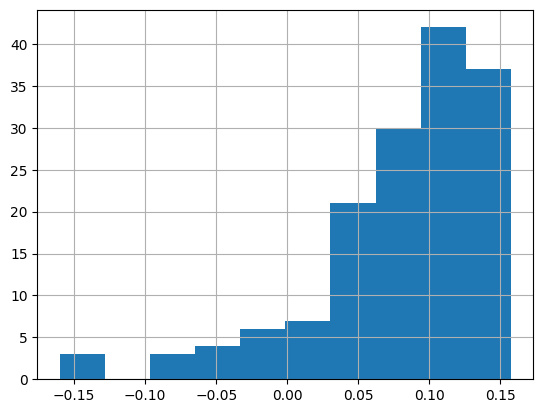

In [42]:
df["anomaly_score"].hist()

In [45]:
df["rule_label"] = (
    (df["heart_rate_bpm"] > 120) |
    (df["blood_oxygen_saturation"] < 90) |
    (df["skin_temperature_celsius"] > 38)
).astype(int)

In [46]:
from sklearn.metrics import classification_report

pred = (df["anomaly_label"] == -1).astype(int)

print(classification_report(df["rule_label"], pred))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83       104
           1       0.75      0.24      0.37        49

    accuracy                           0.73       153
   macro avg       0.74      0.60      0.60       153
weighted avg       0.74      0.73      0.68       153



In [47]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']